# Customer Churn & Retention Intelligence System

## Phase 2 — Data Cleaning and Behavioral Analysis

### Objective

The objective of this phase is to create a reliable customer-transaction dataset for churn analysis while preserving meaningful customer behaviour such as purchases, repeat activity, and returns.

Operational adjustments, duplicate records, accounting entries, and transactions that cannot be linked to identifiable customers are handled separately from genuine customer activity.

In [1]:
#Imports
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Project paths
PROJECT_ROOT = Path.cwd().parent
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

excel_file = RAW_DATA_DIR / "online_retail_II.xlsx"

print("Raw data directory:", RAW_DATA_DIR)
print("Processed data directory:", PROCESSED_DATA_DIR)

Raw data directory: c:\Users\ptbha\OneDrive\Desktop\customer-churn-retention-intelligence\data\raw
Processed data directory: c:\Users\ptbha\OneDrive\Desktop\customer-churn-retention-intelligence\data\processed


In [3]:
#Load both yearly sheets
df_2009_2010 = pd.read_excel(
    excel_file,
    sheet_name="Year 2009-2010"
)

df_2010_2011 = pd.read_excel(
    excel_file,
    sheet_name="Year 2010-2011"
)

df_raw = pd.concat(
    [df_2009_2010, df_2010_2011],
    ignore_index=True
)

print("Raw dataset shape:", df_raw.shape)

Raw dataset shape: (1067371, 8)


In [4]:
#Validate baseline
print("Missing Customer IDs:", df_raw["Customer ID"].isna().sum())
print("Duplicate rows:", df_raw.duplicated().sum())
print("Negative quantities:", (df_raw["Quantity"] < 0).sum())
print("Zero prices:", (df_raw["Price"] == 0).sum())
print("Negative prices:", (df_raw["Price"] < 0).sum())

Missing Customer IDs: 243007
Duplicate rows: 34335
Negative quantities: 22950
Zero prices: 6202
Negative prices: 5


## Step 1 — Remove Exact Duplicate Records

Exact duplicate rows do not represent additional customer behaviour and can artificially increase transaction counts, quantities, and monetary values.

Duplicate removal is therefore performed before further customer-level analysis.

In [5]:
#Create cleaned working copy
df_clean = df_raw.copy()

print("Starting rows:", len(df_clean))

Starting rows: 1067371


In [6]:
#Remove duplicates with audit
rows_before = len(df_clean)

df_clean = df_clean.drop_duplicates().copy()

rows_after = len(df_clean)
rows_removed = rows_before - rows_after

print("Rows before:", rows_before)
print("Duplicates removed:", rows_removed)
print("Rows after:", rows_after)

Rows before: 1067371
Duplicates removed: 34335
Rows after: 1033036


In [7]:
#Validate duplicate removal
print(
    "Remaining duplicate rows:",
    df_clean.duplicated().sum()
)

Remaining duplicate rows: 0


## Step 2 — Handle Missing Customer IDs

Customer ID is required to build customer-level behavioural features such as recency, frequency, monetary value, purchase intervals, and return behaviour.

Transactions without a Customer ID cannot be reliably assigned to a specific customer and are therefore excluded from the customer-modeling dataset.

The original raw dataset remains unchanged.

In [8]:
#Check missing Customer IDs after duplicate removal
missing_customer_rows = df_clean["Customer ID"].isna().sum()
missing_customer_percentage = (
    df_clean["Customer ID"].isna().mean() * 100
)

print("Rows with missing Customer ID:", missing_customer_rows)
print(
    "Missing Customer ID percentage:",
    f"{missing_customer_percentage:.2f}%"
)

Rows with missing Customer ID: 235151
Missing Customer ID percentage: 22.76%


In [9]:
#Inspect unidentified transactions before removing them
unidentified_transactions = df_clean[
    df_clean["Customer ID"].isna()
].copy()

print(
    "Unidentified transaction rows:",
    len(unidentified_transactions)
)

print(
    "Unique unidentified invoices:",
    unidentified_transactions["Invoice"].nunique()
)

print(
    "Negative quantities:",
    (unidentified_transactions["Quantity"] < 0).sum()
)

print(
    "Zero-price rows:",
    (unidentified_transactions["Price"] == 0).sum()
)

unidentified_transactions.head(10)

Unidentified transaction rows: 235151
Unique unidentified invoices: 8752
Negative quantities: 4106
Zero-price rows: 5944


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,NaN,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,NaN,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1058,489548,22195,LARGE HEART MEASURING SPOONS,1,2009-12-01 12:32:00,1.65,NaN,United Kingdom


In [10]:
#Remove missing Customer IDs with audit
rows_before = len(df_clean)

df_clean = df_clean[
    df_clean["Customer ID"].notna()
].copy()

rows_after = len(df_clean)
rows_removed = rows_before - rows_after

print("Rows before:", rows_before)
print("Rows removed:", rows_removed)
print("Rows after:", rows_after)

Rows before: 1033036
Rows removed: 235151
Rows after: 797885


In [11]:
#Validate
print(
    "Remaining missing Customer IDs:",
    df_clean["Customer ID"].isna().sum()
)

print(
    "Customers remaining:",
    df_clean["Customer ID"].nunique()
)

Remaining missing Customer IDs: 0
Customers remaining: 5942


## Step 3 — Classify Customer Transactions

After removing transactions that cannot be linked to a customer,
the remaining records are examined to distinguish normal purchases
from customer returns/cancellations and other unusual transactions.

Return behaviour is preserved because it may provide useful predictive
information for customer churn.

In [12]:
#Recheck quantities and invoice patterns
print("Current rows:", len(df_clean))

print(
    "Negative quantity rows:",
    (df_clean["Quantity"] < 0).sum()
)

print(
    "Zero quantity rows:",
    (df_clean["Quantity"] == 0).sum()
)

print(
    "C-prefixed invoice rows:",
    df_clean["Invoice"]
    .astype(str)
    .str.startswith("C")
    .sum()
)

print(
    "Price == 0 rows:",
    (df_clean["Price"] == 0).sum()
)

print(
    "Price < 0 rows:",
    (df_clean["Price"] < 0).sum()
)

Current rows: 797885
Negative quantity rows: 18390
Zero quantity rows: 0
C-prefixed invoice rows: 18390
Price == 0 rows: 70
Price < 0 rows: 0


In [13]:
#Check whether negative quantities are now mostly returns
negative_customer_transactions = df_clean[
    df_clean["Quantity"] < 0
].copy()

negative_with_c = negative_customer_transactions[
    negative_customer_transactions["Invoice"]
    .astype(str)
    .str.startswith("C")
].copy()

negative_without_c = negative_customer_transactions[
    ~negative_customer_transactions["Invoice"]
    .astype(str)
    .str.startswith("C")
].copy()

print(
    "Negative customer-linked rows:",
    len(negative_customer_transactions)
)

print(
    "C-prefixed negative rows:",
    len(negative_with_c)
)

print(
    "Non-C negative rows:",
    len(negative_without_c)
)

Negative customer-linked rows: 18390
C-prefixed negative rows: 18390
Non-C negative rows: 0


In [14]:
#Inspect any remaining non-C negatives
negative_without_c[
    [
        "Invoice",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "Price",
        "Customer ID",
        "Country"
    ]
].head(30)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


In [15]:
#Check C-prefixed invoice consistency
c_prefixed = df_clean[
    df_clean["Invoice"]
    .astype(str)
    .str.startswith("C")
].copy()

print("Total C-prefixed rows:", len(c_prefixed))

print(
    "C-prefixed rows with Quantity < 0:",
    (c_prefixed["Quantity"] < 0).sum()
)

print(
    "C-prefixed rows with Quantity > 0:",
    (c_prefixed["Quantity"] > 0).sum()
)

print(
    "C-prefixed rows with Price > 0:",
    (c_prefixed["Price"] > 0).sum()
)

Total C-prefixed rows: 18390
C-prefixed rows with Quantity < 0: 18390
C-prefixed rows with Quantity > 0: 0
C-prefixed rows with Price > 0: 18390


## Step 4 — Separate Purchases and Returns

Customer-linked transactions are separated into normal purchases and
returns/cancellations.

Returns are preserved separately because return behaviour may later be
used as a predictive feature for churn.

In [16]:
#Create sales and returns datasets
df_returns = df_clean[
    df_clean["Invoice"]
    .astype(str)
    .str.startswith("C")
].copy()

df_sales = df_clean[
    ~df_clean["Invoice"]
    .astype(str)
    .str.startswith("C")
].copy()

print("Customer-linked rows:", len(df_clean))
print("Sales rows:", len(df_sales))
print("Return rows:", len(df_returns))
print(
    "Check total:",
    len(df_sales) + len(df_returns)
)

Customer-linked rows: 797885
Sales rows: 779495
Return rows: 18390
Check total: 797885


In [17]:
#Validate the split
print(
    "Negative quantities in sales:",
    (df_sales["Quantity"] < 0).sum()
)

print(
    "Positive quantities in returns:",
    (df_returns["Quantity"] > 0).sum()
)

print(
    "C-prefixed invoices in sales:",
    df_sales["Invoice"]
    .astype(str)
    .str.startswith("C")
    .sum()
)

print(
    "Non-C invoices in returns:",
    (
        ~df_returns["Invoice"]
        .astype(str)
        .str.startswith("C")
    ).sum()
)

Negative quantities in sales: 0
Positive quantities in returns: 0
C-prefixed invoices in sales: 0
Non-C invoices in returns: 0


## Step 5 — Review Zero-Price Customer Transactions

A small number of customer-linked transactions have a price of zero.

These records are reviewed separately because they may represent free
items, manual entries, test transactions, or other non-standard activity
and should not automatically contribute to monetary-value calculations.

In [18]:
#Check where the zero-price rows are
print(
    "Zero-price rows in sales:",
    (df_sales["Price"] == 0).sum()
)

print(
    "Zero-price rows in returns:",
    (df_returns["Price"] == 0).sum()
)

Zero-price rows in sales: 70
Zero-price rows in returns: 0


In [19]:
zero_price_sales = df_sales[
    df_sales["Price"] == 0
].copy()

print("Zero-price sales rows:", len(zero_price_sales))

print(
    "Customers affected:",
    zero_price_sales["Customer ID"].nunique()
)

print(
    "Invoices affected:",
    zero_price_sales["Invoice"].nunique()
)

zero_price_sales[
    [
        "Invoice",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "Price",
        "Customer ID",
        "Country"
    ]
].head(30)

Zero-price sales rows: 70
Customers affected: 51
Invoices affected: 61


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
4674,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.0,16126.0,United Kingdom
6781,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,0.0,15658.0,United Kingdom
16107,490727,M,Manual,1,2009-12-07 16:38:00,0.0,17231.0,United Kingdom
18738,490961,22065,CHRISTMAS PUDDING TRINKET POT,1,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
18739,490961,22142,CHRISTMAS CRAFT WHITE FAIRY,12,2009-12-08 15:25:00,0.0,14108.0,United Kingdom
32916,492079,85042,ANTIQUE LILY FAIRY LIGHTS,8,2009-12-15 13:49:00,0.0,15070.0,United Kingdom
40101,492760,21143,ANTIQUE GLASS HEART DECORATION,12,2009-12-18 14:22:00,0.0,18071.0,United Kingdom
47126,493761,79320,FLAMINGO LIGHTS,24,2010-01-06 14:54:00,0.0,14258.0,United Kingdom
48342,493899,22355,"CHARLOTTE BAG , SUKI DESIGN",10,2010-01-08 10:43:00,0.0,12417.0,Belgium
57619,494607,21533,RETRO SPOT LARGE MILK JUG,12,2010-01-15 12:43:00,0.0,16858.0,United Kingdom


### Zero-Price Transaction Decision

Zero-price customer transactions are retained as part of the transaction
history but are excluded from monetary-value calculations.

This prevents non-standard zero-price items from distorting revenue,
average order value, and other monetary features while preserving the
customer's overall purchase activity.

In [20]:
#Create monetary sales dataset
df_sales_value = df_sales[
    df_sales["Price"] > 0
].copy()

print("Sales rows:", len(df_sales))
print("Rows used for monetary analysis:", len(df_sales_value))
print(
    "Zero-price rows excluded from monetary calculations:",
    len(df_sales) - len(df_sales_value)
)

Sales rows: 779495
Rows used for monetary analysis: 779425
Zero-price rows excluded from monetary calculations: 70


In [21]:
#Create sales amount
df_sales_value["SalesAmount"] = (
    df_sales_value["Quantity"]
    * df_sales_value["Price"]
)

df_sales_value[
    [
        "Invoice",
        "Customer ID",
        "Quantity",
        "Price",
        "SalesAmount"
    ]
].head()

,Invoice,Customer ID,Quantity,Price,SalesAmount
0,489434,13085.0,12,6.95,83.4
1,489434,13085.0,12,6.75,81.0
2,489434,13085.0,12,6.75,81.0
3,489434,13085.0,48,2.10,100.8
4,489434,13085.0,24,1.25,30.0


## Step 6 — Standardise Customer Identifier

Customer ID was initially read as a floating-point column because the raw
dataset contained missing values.

After removing transactions without identifiable customers, Customer ID
can be safely converted to an integer identifier.

In [22]:
#Convert Customer ID
for dataframe in [
    df_clean,
    df_sales,
    df_returns,
    df_sales_value
]:
    dataframe["Customer ID"] = (
        dataframe["Customer ID"]
        .astype("int64")
    )

print(df_clean["Customer ID"].dtype)
print(df_sales["Customer ID"].dtype)
print(df_returns["Customer ID"].dtype)
print(df_sales_value["Customer ID"].dtype)

int64
int64
int64
int64


## Customer Behavioral Analysis

Customer purchasing behaviour is analysed at customer level to understand
recency, purchase frequency, monetary value, customer tenure, and
inter-purchase intervals.

These behavioural patterns will later support the definition of customer
churn and the construction of predictive features.

In [23]:
#Determine analysis date
analysis_date = df_sales["InvoiceDate"].max()

print("Analysis date:", analysis_date)

Analysis date: 2011-12-09 12:50:00


In [24]:
#Customer recency
customer_recency = (
    df_sales
    .groupby("Customer ID")["InvoiceDate"]
    .max()
    .reset_index(name="LastPurchaseDate")
)

customer_recency["RecencyDays"] = (
    analysis_date
    - customer_recency["LastPurchaseDate"]
).dt.days

customer_recency.head()

,Customer ID,LastPurchaseDate,RecencyDays
0,12346,2011-01-18 10:01:00,325
1,12347,2011-12-07 15:52:00,1
2,12348,2011-09-25 13:13:00,74
3,12349,2011-11-21 09:51:00,18
4,12350,2011-02-02 16:01:00,309


In [25]:
customer_recency["RecencyDays"].describe()

count    5881.000000
mean      200.457745
std       209.474135
min         0.000000
25%        25.000000
50%        95.000000
75%       379.000000
max       738.000000
Name: RecencyDays, dtype: float64

In [26]:
#Purchase frequency
customer_frequency = (
    df_sales
    .groupby("Customer ID")["Invoice"]
    .nunique()
    .reset_index(name="PurchaseFrequency")
)

customer_frequency["PurchaseFrequency"].describe()

count    5881.000000
mean        6.287196
std        13.012879
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       398.000000
Name: PurchaseFrequency, dtype: float64

In [27]:
#Customer monetary value
customer_monetary = (
    df_sales_value
    .groupby("Customer ID")["SalesAmount"]
    .sum()
    .reset_index(name="MonetaryValue")
)

customer_monetary["MonetaryValue"].describe()

count      5878.000000
mean       2955.904095
std       14440.852688
min           2.950000
25%         342.280000
50%         867.740000
75%        2248.305000
max      580987.040000
Name: MonetaryValue, dtype: float64

In [28]:
#Customer tenure
customer_dates = (
    df_sales
    .groupby("Customer ID")["InvoiceDate"]
    .agg(
        FirstPurchaseDate="min",
        LastPurchaseDate="max"
    )
    .reset_index()
)

customer_dates["TenureDays"] = (
    customer_dates["LastPurchaseDate"]
    - customer_dates["FirstPurchaseDate"]
).dt.days

customer_dates["TenureDays"].describe()

count    5881.000000
mean      272.883183
std       258.815005
min         0.000000
25%         0.000000
50%       220.000000
75%       511.000000
max       738.000000
Name: TenureDays, dtype: float64

## Inter-Purchase Gap Analysis

Churn should not be defined using an arbitrary inactivity threshold.

To understand normal customer purchasing behaviour, the time between
consecutive purchases is calculated for repeat customers.

The distribution of these inter-purchase gaps will help determine when
customer inactivity becomes unusually long compared with typical
purchasing behaviour.

In [29]:
#Create invoice-level purchase history
invoice_history = (
    df_sales
    .groupby(
        ["Customer ID", "Invoice"],
        as_index=False
    )
    .agg(
        PurchaseDate=("InvoiceDate", "min")
    )
)

invoice_history = invoice_history.sort_values(
    ["Customer ID", "PurchaseDate"]
)

print("Invoice-level purchase records:", len(invoice_history))
print(
    "Customers represented:",
    invoice_history["Customer ID"].nunique()
)

invoice_history.head(10)

Invoice-level purchase records: 36975
Customers represented: 5881


,Customer ID,Invoice,PurchaseDate
0,12346,491725,2009-12-14 08:34:00
1,12346,491742,2009-12-14 11:00:00
2,12346,491744,2009-12-14 11:02:00
3,12346,492718,2009-12-18 10:47:00
4,12346,492722,2009-12-18 10:55:00
5,12346,493410,2010-01-04 09:24:00
6,12346,493412,2010-01-04 09:53:00
7,12346,494450,2010-01-14 13:50:00
8,12346,495295,2010-01-22 13:30:00
9,12346,499763,2010-03-02 13:08:00


In [30]:
#Calculate previous purchase date
invoice_history["PreviousPurchaseDate"] = (
    invoice_history
    .groupby("Customer ID")["PurchaseDate"]
    .shift(1)
)

invoice_history["PurchaseGapDays"] = (
    invoice_history["PurchaseDate"]
    - invoice_history["PreviousPurchaseDate"]
).dt.total_seconds() / 86400

In [31]:
#Extract valid purchase gaps
purchase_gaps = (
    invoice_history["PurchaseGapDays"]
    .dropna()
)

print("Number of purchase gaps:", len(purchase_gaps))

purchase_gaps.describe()

Number of purchase gaps: 31094


count    31094.000000
mean        51.681669
std         75.786619
min          0.000000
25%          6.983333
50%         24.740972
75%         61.804340
max        714.152083
Name: PurchaseGapDays, dtype: float64

In [32]:
#Get useful percentiles
gap_percentiles = purchase_gaps.quantile(
    [
        0.25,
        0.50,
        0.75,
        0.80,
        0.85,
        0.90,
        0.95,
        0.99
    ]
)

gap_percentiles

0.25      6.983333
0.50     24.740972
0.75     61.804340
0.80     76.989167
0.85     99.208403
0.90    134.864653
0.95    206.324549
0.99    368.730826
Name: PurchaseGapDays, dtype: float64

In [33]:
for threshold in [30, 60, 90, 120, 150, 180]:
    percentage = (
        purchase_gaps.gt(threshold).mean() * 100
    )

    print(
        f"Gaps > {threshold:3d} days: "
        f"{percentage:.2f}%"
    )

Gaps >  30 days: 44.77%
Gaps >  60 days: 25.57%
Gaps >  90 days: 17.04%
Gaps > 120 days: 11.80%
Gaps > 150 days: 8.55%
Gaps > 180 days: 6.35%


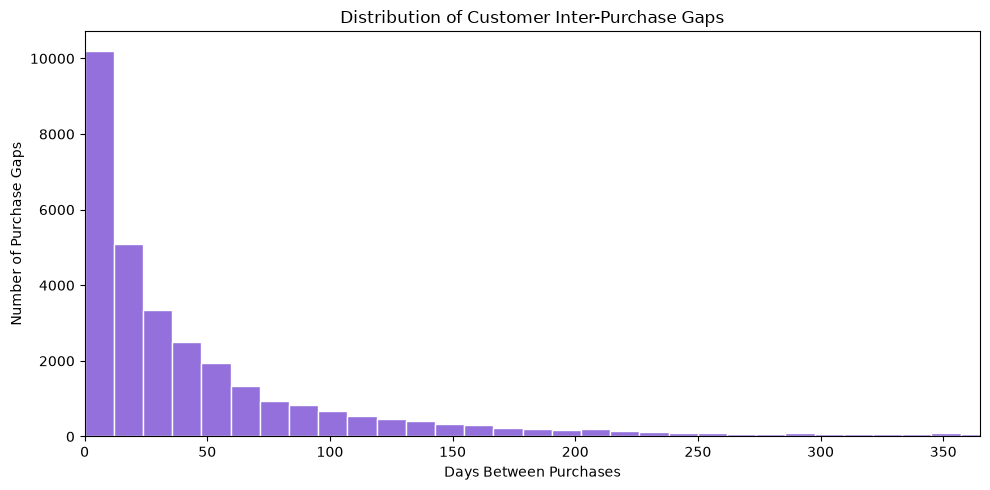

In [34]:
#Visualize the distribution
plt.figure(figsize=(10, 5))

plt.hist(
    purchase_gaps,
    bins=60,
    color="mediumpurple",
    edgecolor="white"
)

plt.xlabel("Days Between Purchases")
plt.ylabel("Number of Purchase Gaps")
plt.title("Distribution of Customer Inter-Purchase Gaps")

plt.xlim(0, 365)

plt.tight_layout()
plt.show()

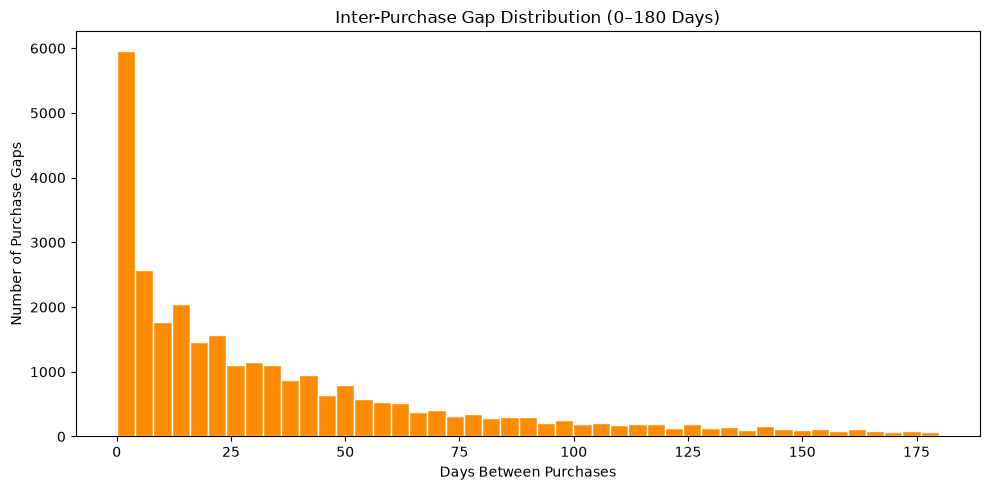

In [35]:
gaps_under_180 = purchase_gaps[
    purchase_gaps <= 180
]

plt.figure(figsize=(10, 5))

plt.hist(
    gaps_under_180,
    bins=45,
    color="darkorange",
    edgecolor="white"
)

plt.xlabel("Days Between Purchases")
plt.ylabel("Number of Purchase Gaps")
plt.title("Inter-Purchase Gap Distribution (0–180 Days)")

plt.tight_layout()
plt.show()

## Purchase-Day Gap Analysis

Some customers have multiple invoices within the same day or within a
short period of time.

For customer inactivity analysis, these invoices may represent the same
purchase occasion. Therefore, purchase activity is also analysed at the
customer-day level.

This provides a more suitable view of the time between distinct customer
shopping days.

In [36]:
#Create customer purchase days
purchase_days = (
    df_sales[
        ["Customer ID", "InvoiceDate"]
    ]
    .assign(
        PurchaseDay=lambda x:
        x["InvoiceDate"].dt.normalize()
    )
    [["Customer ID", "PurchaseDay"]]
    .drop_duplicates()
    .sort_values(
        ["Customer ID", "PurchaseDay"]
    )
    .reset_index(drop=True)
)

print(
    "Unique customer purchase days:",
    len(purchase_days)
)

print(
    "Customers represented:",
    purchase_days["Customer ID"].nunique()
)

purchase_days.head(15)

Unique customer purchase days: 33112
Customers represented: 5881


,Customer ID,PurchaseDay
0,12346,2009-12-14
1,12346,2009-12-18
2,12346,2010-01-04
3,12346,2010-01-14
4,12346,2010-01-22
5,12346,2010-03-02
6,12346,2010-06-28
7,12346,2011-01-18
8,12347,2010-10-31
9,12347,2010-12-07


In [37]:
#Calculate gaps between purchasing days
purchase_days["PreviousPurchaseDay"] = (
    purchase_days
    .groupby("Customer ID")["PurchaseDay"]
    .shift(1)
)

purchase_days["PurchaseDayGap"] = (
    purchase_days["PurchaseDay"]
    - purchase_days["PreviousPurchaseDay"]
).dt.days

purchase_day_gaps = (
    purchase_days["PurchaseDayGap"]
    .dropna()
)

purchase_day_gaps.describe()

count    27231.000000
mean        59.013918
std         78.267838
min          1.000000
25%         13.000000
50%         31.000000
75%         70.000000
max        714.000000
Name: PurchaseDayGap, dtype: float64

In [38]:
purchase_day_gap_percentiles = (
    purchase_day_gaps.quantile(
        [
            0.25,
            0.50,
            0.75,
            0.80,
            0.85,
            0.90,
            0.95,
            0.99
        ]
    )
)

purchase_day_gap_percentiles

0.25     13.0
0.50     31.0
0.75     70.0
0.80     87.0
0.85    111.0
0.90    147.0
0.95    221.0
0.99    377.0
Name: PurchaseDayGap, dtype: float64

In [39]:
#Threshold comparison
for threshold in [
    30,
    60,
    90,
    120,
    150,
    180
]:
    percentage = (
        purchase_day_gaps.gt(threshold).mean()
        * 100
    )

    print(
        f"Purchase-day gaps > {threshold:3d} days: "
        f"{percentage:.2f}%"
    )

Purchase-day gaps >  30 days: 50.67%
Purchase-day gaps >  60 days: 29.00%
Purchase-day gaps >  90 days: 19.29%
Purchase-day gaps > 120 days: 13.38%
Purchase-day gaps > 150 days: 9.72%
Purchase-day gaps > 180 days: 7.23%


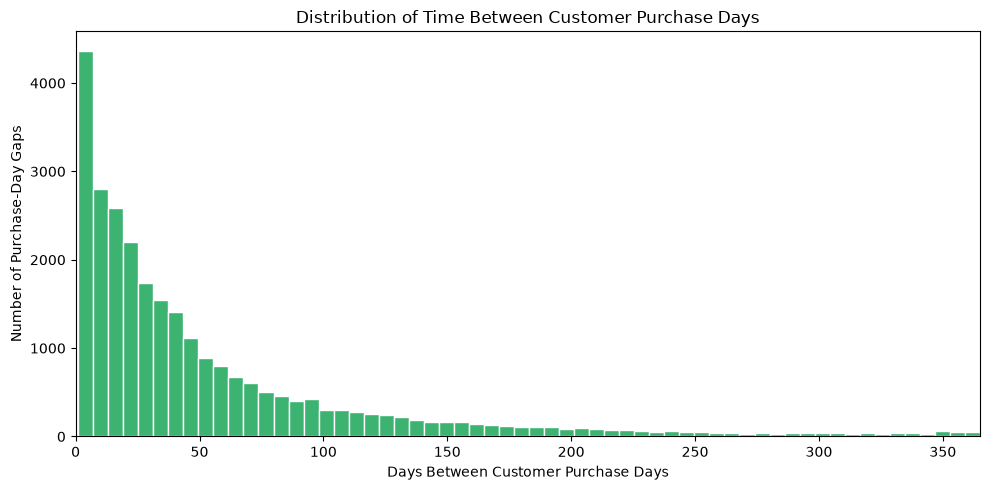

In [40]:
plt.figure(figsize=(10, 5))

plt.hist(
    purchase_day_gaps[
        purchase_day_gaps <= 365
    ],
    bins=60,
    color="mediumseagreen",
    edgecolor="white"
)

plt.xlabel("Days Between Customer Purchase Days")
plt.ylabel("Number of Purchase-Day Gaps")
plt.title(
    "Distribution of Time Between Customer Purchase Days"
)

plt.xlim(0, 365)

plt.tight_layout()
plt.show()

## Customer-Level Purchase Interval Analysis

Global purchase-gap distributions provide an overall view of customer
behaviour, but individual customers may have very different purchasing
patterns.

To understand this variation, the typical purchase interval is calculated
for each repeat customer using the median number of days between purchase
days.

In [41]:
#Median purchase gap per customer
customer_gap_summary = (
    purchase_days
    .dropna(subset=["PurchaseDayGap"])
    .groupby("Customer ID")["PurchaseDayGap"]
    .agg(
        MedianPurchaseGap="median",
        MeanPurchaseGap="mean",
        MaxPurchaseGap="max",
        PurchaseGapCount="count"
    )
    .reset_index()
)

customer_gap_summary.head()

,Customer ID,MedianPurchaseGap,MeanPurchaseGap,MaxPurchaseGap,PurchaseGapCount
0,12346,17.0,57.142857,204.0,7
1,12347,54.0,57.428571,90.0,7
2,12348,75.0,90.750000,173.0,4
3,12349,163.0,190.333333,389.0,3
4,12352,16.5,44.500000,182.0,8


In [42]:
print(
    "Customers with at least one purchase gap:",
    len(customer_gap_summary)
)

customer_gap_summary[
    "MedianPurchaseGap"
].describe()

Customers with at least one purchase gap: 4189


count    4189.000000
mean      102.099188
std       104.876481
min         1.000000
25%        34.000000
50%        63.500000
75%       130.000000
max       714.000000
Name: MedianPurchaseGap, dtype: float64

In [43]:
#Percentiles of customer-specific median gaps
customer_gap_percentiles = (
    customer_gap_summary[
        "MedianPurchaseGap"
    ]
    .quantile(
        [
            0.25,
            0.50,
            0.75,
            0.80,
            0.85,
            0.90,
            0.95,
            0.99
        ]
    )
)

customer_gap_percentiles

0.25     34.0
0.50     63.5
0.75    130.0
0.80    157.0
0.85    189.0
0.90    239.2
0.95    345.7
0.99    513.0
Name: MedianPurchaseGap, dtype: float64

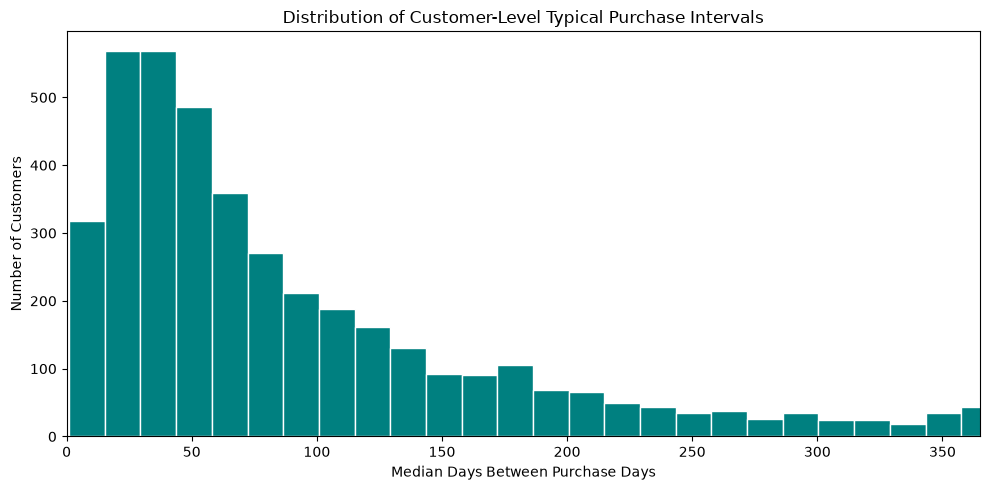

In [44]:
#Plot customer-level typical gaps
plt.figure(figsize=(10, 5))

plt.hist(
    customer_gap_summary[
        "MedianPurchaseGap"
    ],
    bins=50,
    color="teal",
    edgecolor="white"
)

plt.xlabel("Median Days Between Purchase Days")
plt.ylabel("Number of Customers")
plt.title(
    "Distribution of Customer-Level Typical Purchase Intervals"
)

plt.xlim(0, 365)

plt.tight_layout()
plt.show()

In [45]:
#Compare customer inactivity with their own typical gap
customer_inactivity = (
    customer_recency
    .merge(
        customer_gap_summary[
            [
                "Customer ID",
                "MedianPurchaseGap",
                "PurchaseGapCount"
            ]
        ],
        on="Customer ID",
        how="left"
    )
)

customer_inactivity.head()

,Customer ID,LastPurchaseDate,RecencyDays,MedianPurchaseGap,PurchaseGapCount
0,12346,2011-01-18 10:01:00,325,17.0,7.0
1,12347,2011-12-07 15:52:00,1,54.0,7.0
2,12348,2011-09-25 13:13:00,74,75.0,4.0
3,12349,2011-11-21 09:51:00,18,163.0,3.0
4,12350,2011-02-02 16:01:00,309,NaN,NaN


In [46]:
#Create inactivity ratio
repeat_customer_inactivity = (
    customer_inactivity[
        customer_inactivity[
            "MedianPurchaseGap"
        ].notna()
    ]
    .copy()
)

repeat_customer_inactivity[
    "InactivityRatio"
] = (
    repeat_customer_inactivity[
        "RecencyDays"
    ]
    /
    repeat_customer_inactivity[
        "MedianPurchaseGap"
    ]
)

repeat_customer_inactivity[
    "InactivityRatio"
].describe()

count    4189.000000
mean        4.250638
std        22.549253
min         0.000000
25%         0.248062
50%         0.745455
75%         2.468085
max       735.000000
Name: InactivityRatio, dtype: float64

In [47]:
for threshold in [1, 1.5, 2, 2.5, 3]:

    percentage = (
        repeat_customer_inactivity[
            "InactivityRatio"
        ]
        .gt(threshold)
        .mean()
        * 100
    )

    print(
        f"Inactivity ratio > {threshold}: "
        f"{percentage:.2f}%"
    )

Inactivity ratio > 1: 43.04%
Inactivity ratio > 1.5: 34.59%
Inactivity ratio > 2: 29.05%
Inactivity ratio > 2.5: 24.80%
Inactivity ratio > 3: 21.91%


## Churn Definition

Customer churn is defined using a 180-day inactivity window.

The threshold was selected based on observed purchase behaviour:

- Median purchase-day gap: 31 days
- 75% of purchase-day gaps are within 70 days
- 90% are within 147 days
- Only about 7% of historical purchase-day gaps exceed 180 days

A 180-day threshold therefore provides a conservative definition of
customer inactivity while reducing the risk of classifying customers
with naturally long purchasing cycles as churned.

A fixed global threshold is used because it can be applied consistently
to both repeat and single-purchase customers.

In [48]:
#Define observation and outcome periods
CHURN_WINDOW_DAYS = 180

dataset_end_date = df_sales["InvoiceDate"].max()

cutoff_date = (
    dataset_end_date
    - pd.Timedelta(days=CHURN_WINDOW_DAYS)
)

print("Dataset end date :", dataset_end_date)
print("Observation cutoff:", cutoff_date)
print("Churn window      :", CHURN_WINDOW_DAYS, "days")

Dataset end date : 2011-12-09 12:50:00
Observation cutoff: 2011-06-12 12:50:00
Churn window      : 180 days


In [49]:
#Split observation and future periods
observation_sales = df_sales[
    df_sales["InvoiceDate"] <= cutoff_date
].copy()

future_sales = df_sales[
    df_sales["InvoiceDate"] > cutoff_date
].copy()

print("Observation-period rows:", len(observation_sales))
print("Future-period rows:", len(future_sales))

print(
    "Observation customers:",
    observation_sales["Customer ID"].nunique()
)

print(
    "Future customers:",
    future_sales["Customer ID"].nunique()
)

Observation-period rows: 540816
Future-period rows: 238679
Observation customers: 4979
Future customers: 3479


In [50]:
#Build eligible customer population
eligible_customers = (
    observation_sales["Customer ID"]
    .drop_duplicates()
    .to_frame()
)

print(
    "Customers eligible for churn prediction:",
    len(eligible_customers)
)

Customers eligible for churn prediction: 4979


In [51]:
#Identify customers who returned
future_customers = set(
    future_sales["Customer ID"].unique()
)

eligible_customers["ReturnedWithin180Days"] = (
    eligible_customers["Customer ID"]
    .isin(future_customers)
    .astype(int)
)

eligible_customers.head()

,Customer ID,ReturnedWithin180Days
0,13085,1
12,13078,1
31,15362,0
54,18102,1
71,12682,1


In [52]:
#Create churn label
eligible_customers["Churn"] = (
    1 - eligible_customers["ReturnedWithin180Days"]
)

eligible_customers.head()

,Customer ID,ReturnedWithin180Days,Churn
0,13085,1,0
12,13078,1,0
31,15362,0,1
54,18102,1,0
71,12682,1,0


In [53]:
#Check class distribution
churn_distribution = (
    eligible_customers["Churn"]
    .value_counts()
    .sort_index()
)

print("Churn = 0 (returned):", churn_distribution.get(0, 0))
print("Churn = 1 (churned) :", churn_distribution.get(1, 0))

print(
    "\nChurn rate:",
    f"{eligible_customers['Churn'].mean() * 100:.2f}%"
)

Churn = 0 (returned): 2577
Churn = 1 (churned) : 2402

Churn rate: 48.24%


In [54]:
eligible_customers["Churn"].value_counts(
    normalize=True
).mul(100).round(2)

Churn
0    51.76
1    48.24
Name: proportion, dtype: float64

In [55]:
# Save processed datasets for feature engineering

PROCESSED_DATA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

df_sales.to_csv(
    PROCESSED_DATA_DIR / "clean_sales_transactions.csv",
    index=False
)

df_returns.to_csv(
    PROCESSED_DATA_DIR / "customer_returns.csv",
    index=False
)

eligible_customers.to_csv(
    PROCESSED_DATA_DIR / "customer_churn_labels.csv",
    index=False
)

print("Processed datasets saved successfully.")

print(
    "\nSales file:",
    PROCESSED_DATA_DIR / "clean_sales_transactions.csv"
)

print(
    "Returns file:",
    PROCESSED_DATA_DIR / "customer_returns.csv"
)

print(
    "Labels file:",
    PROCESSED_DATA_DIR / "customer_churn_labels.csv"
)

Processed datasets saved successfully.

Sales file: c:\Users\ptbha\OneDrive\Desktop\customer-churn-retention-intelligence\data\processed\clean_sales_transactions.csv
Returns file: c:\Users\ptbha\OneDrive\Desktop\customer-churn-retention-intelligence\data\processed\customer_returns.csv
Labels file: c:\Users\ptbha\OneDrive\Desktop\customer-churn-retention-intelligence\data\processed\customer_churn_labels.csv


In [58]:
# Validate saved files

files_to_check = [
    "clean_sales_transactions.csv",
    "customer_returns.csv",
    "customer_churn_labels.csv"
]

for filename in files_to_check:
    file_path = PROCESSED_DATA_DIR / filename

    print(
        filename,
        "->",
        "Saved" if file_path.exists() else "Missing"
    )

clean_sales_transactions.csv -> Saved
customer_returns.csv -> Saved
customer_churn_labels.csv -> Saved


## Summary

The customer transaction data was cleaned and separated into normal sales activity and customer returns/cancellations.

Duplicate records and transactions without identifiable customers were removed from the customer-modeling dataset.

Customer purchasing behaviour was analysed using recency, frequency, monetary value, customer tenure, invoice gaps, purchase-day gaps, and customer-specific purchase intervals.

Based on the observed purchase behaviour, a 180-day inactivity window was selected as the churn definition.

To avoid data leakage, the dataset was divided into an observation period and a future 180-day outcome window.

The resulting churn dataset contains 4,979 eligible customers:

- 2,577 returned within 180 days
- 2,402 did not return
- Churn rate: 48.24%

The next phase will focus on customer-level feature engineering using only information available before the observation cutoff date.